# 9. Shor's Algorithm

Shor's algorithm factors a composite number `N` using a quantum
subroutine called **period finding**, combined with simple classical
math (the `gcd` function). This is the algorithm that would let a
large enough quantum computer break RSA encryption.

We factor `N = 15` (into `3 x 5`) using `a = 7`, a number that has
no common factors with 15.

The steps are:
1. Build a quantum circuit that finds the **period** `r` of
   `7^x mod 15` (how often the sequence 7, 49, 343, ... mod 15
   repeats).
2. Use `r` classically to compute the factors of 15.

## Step 1: Import libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_distribution, plot_histogram
from fractions import Fraction
import math

simulator = AerSimulator()

N = 15          # the number we want to factor
a = 7           # our chosen base, coprime with 15
n_count = 3     # number of "counting" qubits (controls precision)

## Step 2: Build the circuit

- `n_count` qubits (the "counting register") start in superposition.
- 4 more qubits (the "work register") hold the number we multiply,
  starting at `|1>`.
- For each counting qubit, we apply a controlled multiply-by-`7 mod
  15` operation, repeated `2^q` times.
- Finally, an inverse Quantum Fourier Transform (QFT) turns the
  period information into something we can measure directly.

In [2]:
qc = QuantumCircuit(n_count + 4, n_count)

# Counting register in superposition
for q in range(n_count):
    qc.h(q)

# Work register starts at |1>
qc.x(n_count)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=7, num_clbits=0, params=[]), qubits=(<Qubit register=(7, "q"), index=0>, <Qubit register=(7, "q"), index=1>, <Qubit register=(7, "q"), index=2>, <Qubit register=(7, "q"), index=3>, <Qubit register=(7, "q"), index=4>, <Qubit register=(7, "q"), index=5>, <Qubit register=(7, "q"), index=6>), clbits=())

### Controlled multiplication by 7 mod 15

Multiplying by 7 mod 15 happens to correspond to a simple pattern of
SWAP and X gates on the 4 work qubits. We repeat this pattern
`2^q` times for counting qubit `q`, and make the whole thing
controlled by that qubit.

In [3]:
for q in range(n_count):
    power = 2 ** q

    U = QuantumCircuit(4, name=f"7^{power} mod 15")
    for _ in range(power):
        U.swap(0, 1)
        U.swap(1, 2)
        U.swap(2, 3)
        for i in range(4):
            U.x(i)

    controlled_U = U.control()
    qc.append(controlled_U, [q] + [n_count + i for i in range(4)])

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=7, num_clbits=0, params=[]), qubits=(<Qubit register=(7, "q"), index=0>, <Qubit register=(7, "q"), index=1>, <Qubit register=(7, "q"), index=2>, <Qubit register=(7, "q"), index=3>, <Qubit register=(7, "q"), index=4>, <Qubit register=(7, "q"), index=5>, <Qubit register=(7, "q"), index=6>), clbits=())

### Inverse Quantum Fourier Transform

This converts the phase information stored across the counting
qubits into a measurable bit pattern.

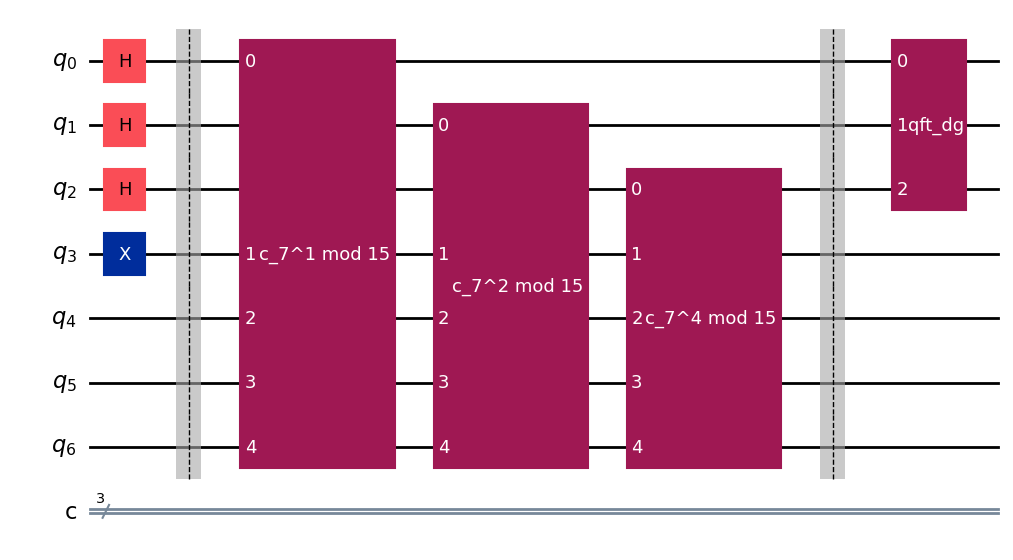

In [4]:
qc.append(QFTGate(n_count).inverse(), range(n_count))

qc.draw("mpl", fold=200)

## Step 3: Look at the state before measuring

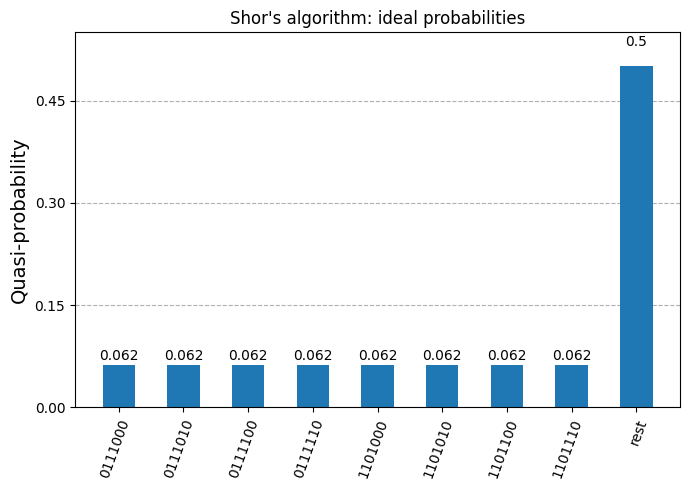

In [5]:
probs = Statevector(qc).probabilities_dict()
plot_distribution(probs, title="Shor's algorithm: ideal probabilities", number_to_keep=8)

## Step 4: Measure the counting register

In [6]:
qc.measure(range(n_count), range(n_count))

compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit, shots=1, memory=True).result()
reading = result.get_memory()[0]

print("Measured bitstring:", reading)

Measured bitstring: 000


## Step 5: Turn the measurement into the period `r`

In [7]:
phase = int(reading, 2) / (2 ** n_count)
frac = Fraction(phase).limit_denominator(N)
r = frac.denominator

print("Measured phase:", phase)
print("Candidate period r:", r)

Measured phase: 0.0
Candidate period r: 1


## Step 6: Use `r` to compute the factors classically

If `r` is even, `gcd(a^(r/2) - 1, N)` and `gcd(a^(r/2) + 1, N)`
usually give the two factors of `N`.

In [8]:
if r % 2 == 0:
    factor_1 = math.gcd(a ** (r // 2) - 1, N)
    factor_2 = math.gcd(a ** (r // 2) + 1, N)
    print(f"Candidate factors of {N}: {factor_1} and {factor_2}")

    non_trivial = [g for g in (factor_1, factor_2) if g not in (1, N)]
    if non_trivial:
        factor = non_trivial[0]
        other = N // factor
        print(f"\nSUCCESS: {N} = {factor} x {other}")
    else:
        print("\nThose factors were trivial (1 or N) -- re-run this notebook to try again.")
else:
    print("\nMeasured an odd period -- re-run this notebook to try again.")
    print("(Quantum measurement is probabilistic, so this can happen sometimes.)")


Measured an odd period -- re-run this notebook to try again.
(Quantum measurement is probabilistic, so this can happen sometimes.)


## Step 7: See many shots at once

Re-running with many shots shows the distribution of measurement
outcomes, most of which correspond to valid periods of 7 mod 15.

Measurement counts: {'100': 244, '110': 258, '010': 256, '000': 266}


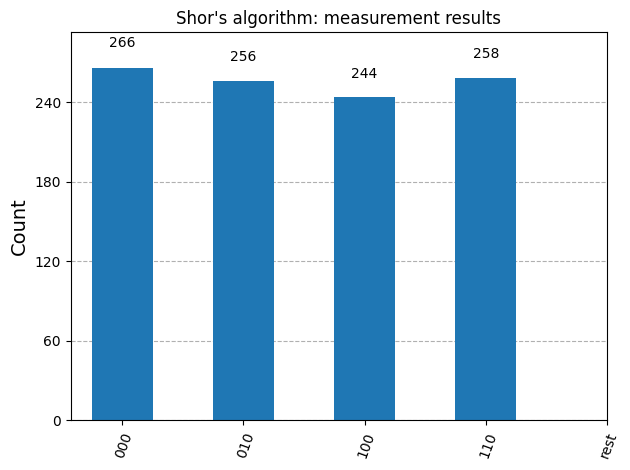

In [9]:
counts = simulator.run(compiled_circuit, shots=1024).result().get_counts()
print("Measurement counts:", counts)
plot_histogram(counts, title="Shor's algorithm: measurement results", number_to_keep=8)